# ROCIO-IBEB - series areales
***

***Autor:** Javier Díez Sierra*<br>
***Fecha:** 15-04-2026*<br>

**Introducción:**<br>
En este _notebook_ se calculan las series meteorológicas areales de las cuencas de BEAVERS-ES a partir de los datos meteorológicos de [ROCIO-IBEB](https://www.aemet.es/es/serviciosclimaticos/cambio_climat/datos_diarios/ayuda/rejilla_5km). Los datos han sido descargados de la página oficial de AEMET: https://www.aemet.es/es/serviciosclimaticos/cambio_climat/datos_diarios?w=1 

Las series de ROCIO-IBEB empiezan el 1 de enero de 1950 y terminan el 31 de diciembre de 2022. Ya que las series de aforos comienzan el 1 de enero de 1979, usaremos dicho periodo como fecha inicial.

En este notebook estamos usando datos de ROCIO-IBEB interpolados a una malla regular de 5x5km, pero se podría trabajar con la proyección original en la malla rotada usando el paquete rio, aunque no deberían existir muchas diferencias en los resultados al tratarse de datos areales medios en sub-cuencas.

In [3]:
import os
import xarray as xr
import numpy as np
import xclim
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from xclim.core.units import convert_units_to

In [16]:
from ocab.config import Config
from ocab.basins.stats import read_data, read_pixarea, basin_statistics

# load configuration file
cfg = Config('config_BEAVERS_v100.yml')

# load basins shapefile
file = '../../docs/layers/reservoirs_basins_3sec.parquet'
basins = gpd.read_parquet(file)

# load pixel area to weigh the statistics
#pixarea = read_pixarea(cfg.path_efas / 'maps' / 'pixarea_iberian_01min.nc')
#pixarea = pixarea.rio.write_crs(cfg.crs)

In [7]:
def traverseDir(root, end):
    for (dirpath, dirnames, filenames) in os.walk(root):
        for file in filenames:
            if file.endswith((end)):
                yield os.path.join(dirpath, file)

In [8]:
root = '/lustre/gmeteo/PTICLIMA/DATA/OBSERVATIONS/AEMET-5KM/data/Iberia/day/pcp/'
root = '/lustre/gmeteo/PTICLIMA/DATA/OBSERVATIONS/AEMET-5KM-regular/data/Iberia/day/'

In [ ]:
# load meteorological data
data_pr = xr.open_mfdataset(np.sort(list(traverseDir(f"{root}/pr/", ".nc"))), 
                            concat_dim="time", combine="nested")
data_tasmax = xr.open_mfdataset(np.sort(list(traverseDir(f"{root}/tasmax/", ".nc"))), 
                                concat_dim="time", combine="nested")
data_tasmin = xr.open_mfdataset(np.sort(list(traverseDir(f"{root}/tasmin/", ".nc"))), 
                                concat_dim="time", combine="nested")

In [10]:
# Calculate Potential Evapotranspiration using Hargreaves et al. (1985, 1994); https://doi.org/10.13031/2013.26773)
data_pet = xclim.indices.potential_evapotranspiration(tasmin=data_tasmin['tasmin'], 
                                                      tasmax=data_tasmax['tasmax'], 
                                                      method='HG85')
data_pet = (data_pet*86400).to_dataset(name = 'e0')
data_pet['e0'].attrs['units'] = 'mm/d'

In [11]:
# Calculate mean teamperatura
data_tas = (data_tasmax['tasmax'] + data_tasmin['tasmin']) / 2
data_tas = data_tas.rename('ta')

In [12]:
data = xr.merge([data_pr, data_tas, data_pet])

In [13]:
data = data.sel(time=slice("1979-01-01", "2021-12-31"))

data = data.rio.set_spatial_dims(x_dim="rlon", y_dim="rlat")
data = data.rio.write_crs(
    "+proj=ob_tran +o_proj=longlat +o_lat_p=39.25 +o_lon_p=-162"
)

In [14]:
data = data.rio.write_crs(cfg.crs)
print(f"{data.nbytes / 1e9:.2f} GB")

11.77 GB


In [ ]:
# compute statistics
results = basin_statistics(
    data=data[['ta', 'e0', 'pr']],
    basins=basins,
    statistic='mean',
    weight=None,
    decimals=1,
    overwrite=True,
    output=cfg.path_dataset / 'preprocessing' / 'catchstats' / 'meteo'/ 'ROCIO-IBEB'
)

In [20]:
def plot_mean_maps(
    geo_df,
    parquet_files,
    start_period=None,
    end_period=None,
    months=None
):
    """
    geo_df: GeoDataFrame with columns ['ID', 'geometry', ...]
    parquet_files: dict {id: path_parquet}
    
    start_period: str or datetime (e.g. "2000-01-01")
    end_period: str or datetime (e.g. "2010-12-31")
    months: list of months (e.g. [6, 7, 8] for summer)
    """

    # --- 1. load and concatenate time series ---
    dfs = []
    for id_, path in parquet_files.items():
        df = pd.read_parquet(path, engine="pyarrow")
        
        df = df.reset_index()

        # Ensure time column exists (adjust name if needed)
        if "time" not in df.columns:
            raise ValueError("Expected a 'time' column in the data")

        df["time"] = pd.to_datetime(df["time"])

        # --- TIME FILTERS ---
        if start_period is not None:
            df = df[df["time"] >= pd.to_datetime(start_period)]

        if end_period is not None:
            df = df[df["time"] <= pd.to_datetime(end_period)]

        if months is not None:
            df = df[df["time"].dt.month.isin(months)]

        df["id"] = df["id"].astype(int)
        dfs.append(df)

    data = pd.concat(dfs)

    # --- 2. compute mean values per basin ---
    means = (
        data.groupby("id")[["ta_mean", "e0_mean", "pr_mean"]]
        .mean()
        .reset_index()
    )

    # --- 3. merge with spatial data ---
    gdf = geo_df.copy()
    gdf = gdf.merge(means, left_on="ID", right_on="id", how="left")

    # --- 4. plot maps ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    variables = ["ta_mean", "e0_mean", "pr_mean"]
    titles = ["Mean Temperature", "Mean E0", "Mean Precipitation"]

    for ax, var, title in zip(axes, variables, titles):
        gdf.plot(column=var, ax=ax, legend=True, cmap="viridis")
        ax.set_title(title)
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()

In [26]:
parquet_files = {
    int(p.stem): str(p)
    for p in (cfg.path_dataset / 'preprocessing' / 'catchstats' / 'meteo' / 'ROCIO-IBEB').glob("*.parquet")
}

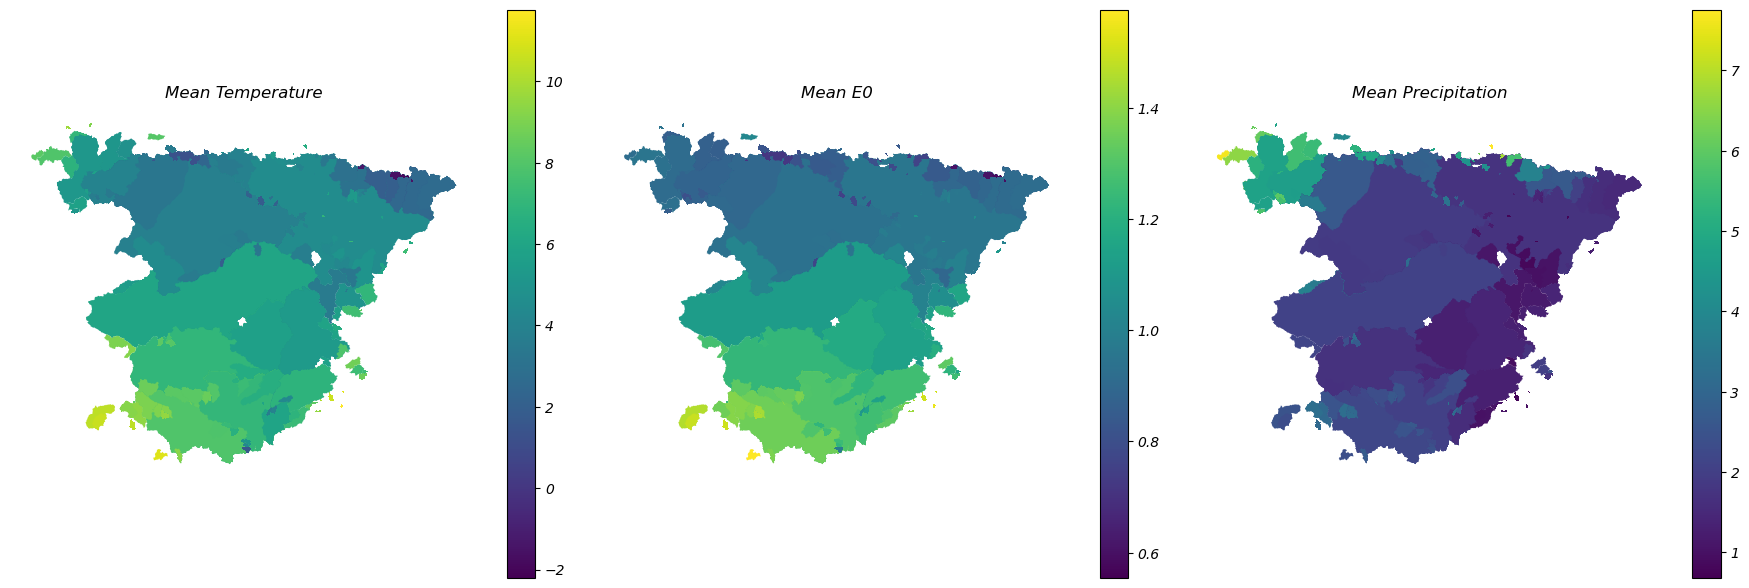

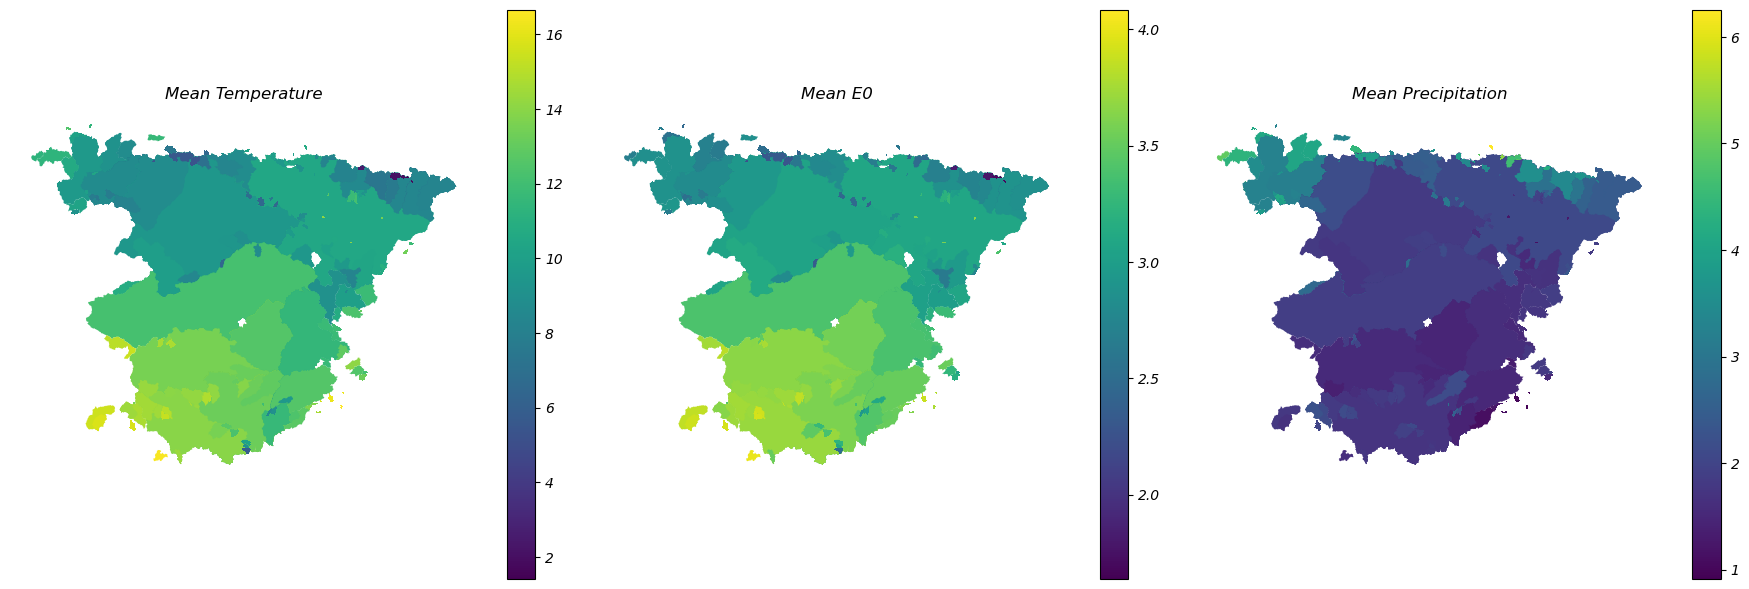

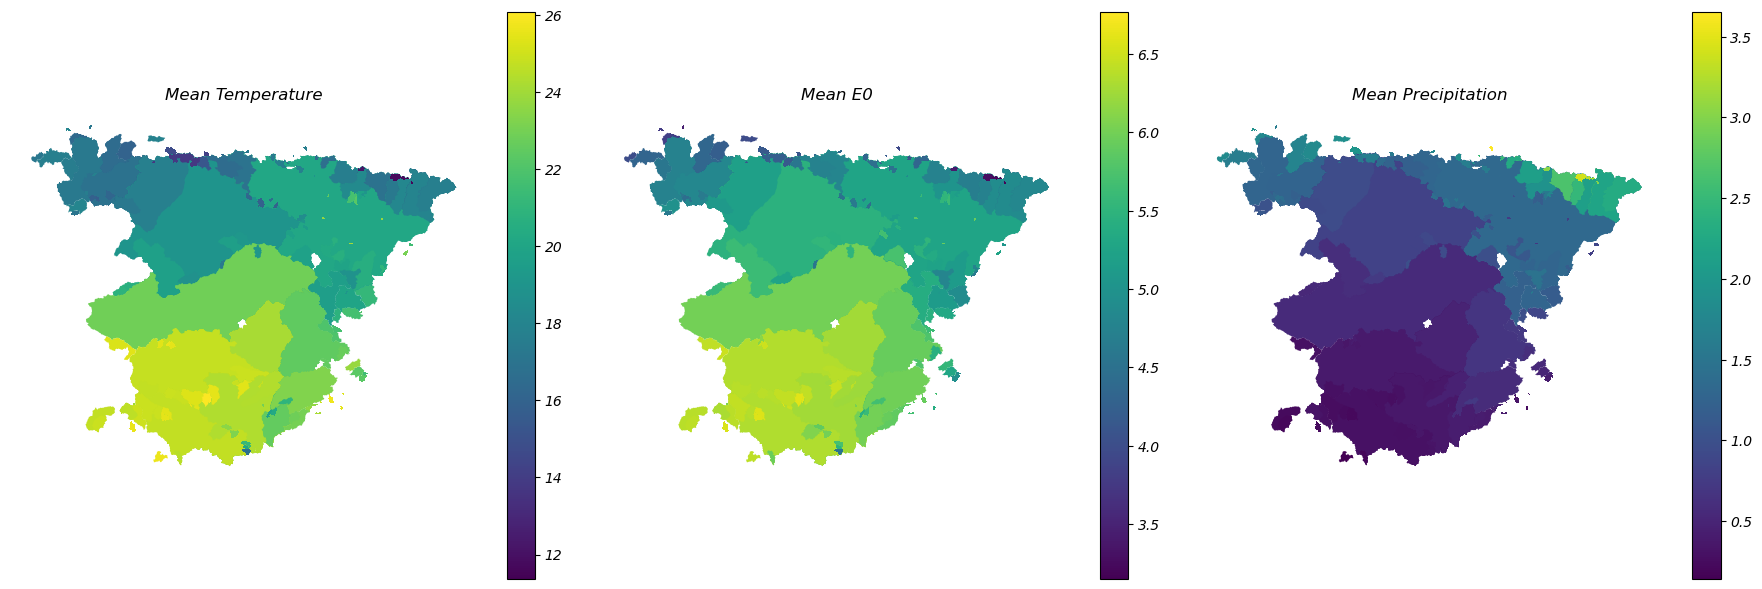

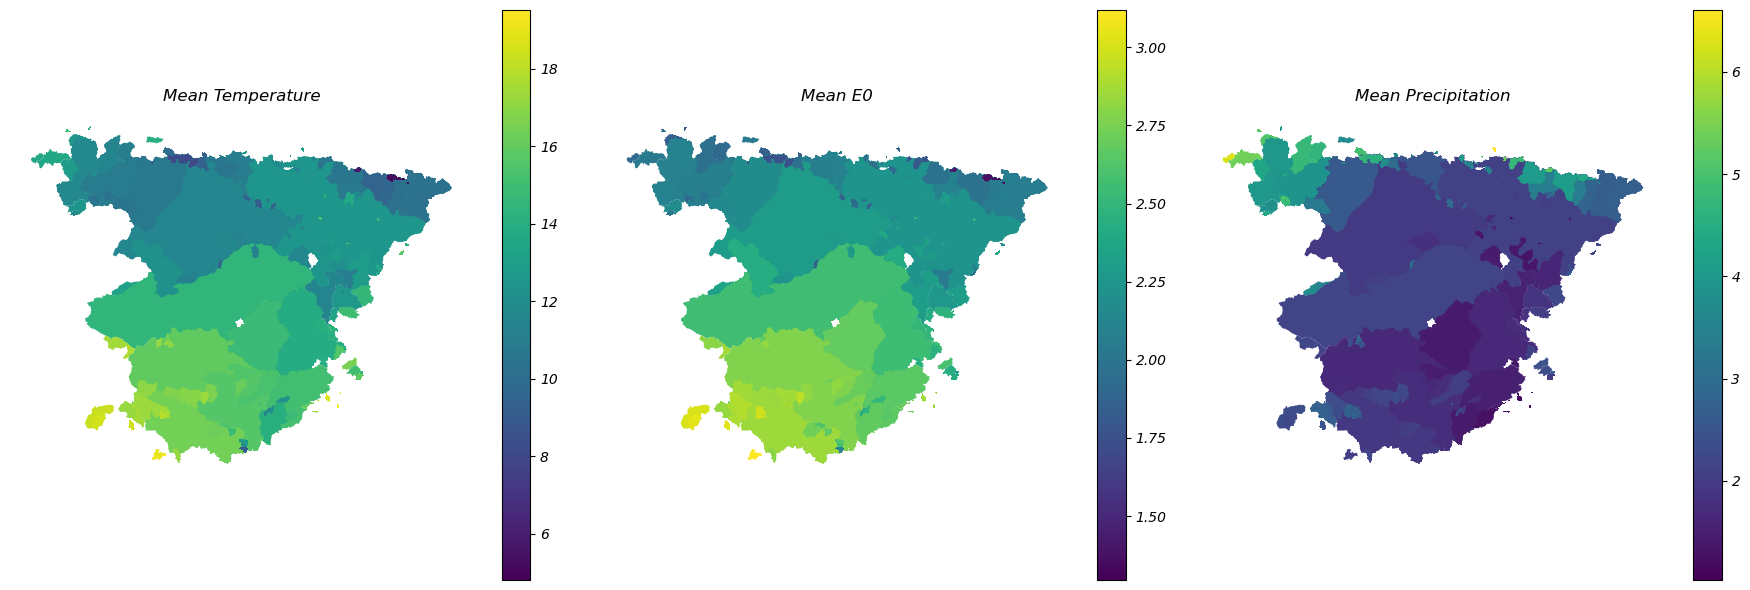

In [27]:
for season in [[12, 1, 2], [3, 4, 5], [6, 7, 8], [9, 10, 11]]:
    plot_mean_maps(basins, 
                   parquet_files, 
                   start_period="1979-01-01", end_period="2021-12-31", 
                   months=season)